# Structural and Optical Analysis of MAPbI₃ Perovskite

This project investigates the structural and optical properties of methylammonium 
lead iodide (MAPbI₃) perovskite. The structural characteristics were previously 
analyzed using X-ray diffraction (XRD), including d-spacing and crystallite size 
determination 
[MAPbI3_XRD_Analysis](https://github.com/Sobia945/MAPbI3_XRD_Analysis) repository). 
The present work extends this analysis to the optical properties of MAPbI₃ thin 
films using literature refractive index ($n$) and extinction coefficient ($k$) 
data and the Transfer Matrix Method (TMM). The optical response of an 
Air/MAPbI₃/Glass structure is modeled in terms of reflectance, transmittance, 
and absorptance.

## Theory

### Complex Refractive Index

The optical properties of a material are described by its complex refractive index:

$$\tilde{n} = n + ik$$

where $n$ is the real refractive index, which describes light propagation and 
reflection, and $k$ is the extinction coefficient, which describes absorption 
within the material.

### Transfer Matrix Method (TMM)

The Transfer Matrix Method (TMM) describes the propagation of light through a 
multilayer thin-film structure, accounting for reflection and transmission at 
interfaces and interference within the layers. For a given layer stack, TMM is 
used to calculate the reflectance ($R$), transmittance ($T$), and absorptance 
($A$) as functions of wavelength, layer thickness, and angle of incidence.

By energy conservation:

$$R + T + A = 1$$

### Absorption Coefficient

The absorption coefficient is related to the extinction coefficient by:

$$\alpha = \frac{4\pi k}{\lambda}$$

where $\lambda$ is the wavelength of light, expressed in the same length units 
used for $\alpha$.

### Methodology

Experimental optical constant *n* and *k* data for MAPbI₃ were obtained from the supplementary dataset of Phillips et al. (2015), *"Dispersion relation data for methylammonium lead triiodide perovskite deposited on a (100) silicon wafer,"* covering wavelengths from 300–1501 nm.

A 500 nm MAPbI₃ absorber layer was modeled between air and a non-dispersive glass substrate ($n = 1.5$, $k = 0$). The wavelength-dependent reflectance ($R$), transmittance ($T$), and absorptance ($A$) were calculated using the Transfer Matrix Method (TMM) in Python with the `tmm` package. Both s- and p-polarized responses were averaged to represent unpolarized light, and $R + T + A = 1$ was verified.

The effects of MAPbI₃ thickness (100–1000 nm) and incidence angle (0°, 30°, and 60°) were also investigated. The absorption coefficient was calculated from $k$ to characterize the intrinsic optical absorption of MAPbI₃.

For experimental comparison, EQE data were digitized from Fig. 3b of Lin et al. (2015), *"Electro-optics of perovskite solar cells,"* and qualitatively compared with the simulated absorptance.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Optical_data/1-s2.0-S2352340915002747-mmc1.csv")

In [3]:
data.head()

,Wavelength (nm),n,k
0,300.009583,1.980725,0.559247
1,301.600861,1.974124,0.563854
2,303.192139,1.967736,0.569127
3,304.783417,1.961613,0.575073
4,306.374725,1.955809,0.581694


In [4]:
data.columns

Index(['Wavelength (nm)', 'n', 'k'], dtype='str')

In [5]:
data.shape

(586, 3)

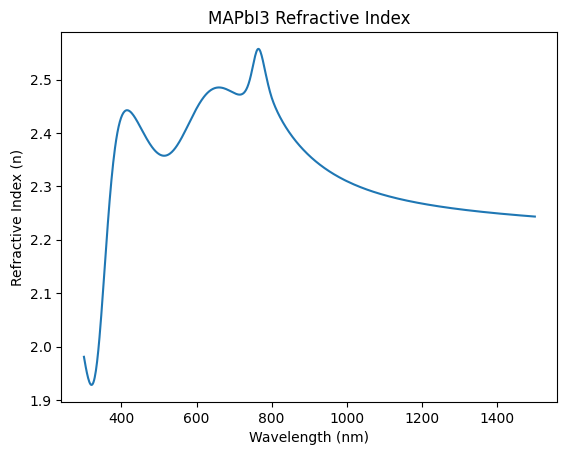

In [6]:
import matplotlib.pyplot as plt

plt.plot(data["Wavelength (nm)"], data["n"])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index (n)")
plt.title("MAPbI3 Refractive Index")
plt.show()

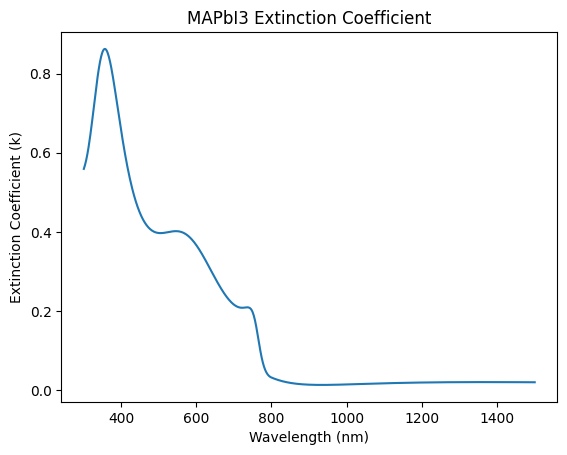

In [7]:
plt.plot(data["Wavelength (nm)"], data["k"])

plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction Coefficient (k)")
plt.title("MAPbI3 Extinction Coefficient")
plt.show()

#### Interpretation of n and k 

The refractive index n increases from about 2.0 in the UV region to a maximum of approximately 2.55 around 750–800 nm, followed by a gradual decrease toward ~2.25 in the NIR. The features in the visible region are associated with the optical dispersion of MAPbI₃(Phillips et al., 2015).

The extinction coefficient k is relatively high in the UV-blue region, indicating strong optical absorption. It decreases significantly toward 780–800 nm, corresponding to the absorption edge of MAPbI₃ and its bandgap of approximately 1.6 eV. At longer wavelengths, k becomes very small, indicating weak absorption and leading to the reduced absorptance observed in the TMM results.

In [8]:
data["n_complex"] = data["n"] + 1j * data["k"]

In [9]:
data.head()

,Wavelength (nm),n,k,n_complex
0,300.009583,1.980725,0.559247,1.980725+0.559247j
1,301.600861,1.974124,0.563854,1.974124+0.563854j
2,303.192139,1.967736,0.569127,1.967736+0.569127j
3,304.783417,1.961613,0.575073,1.961613+0.575073j
4,306.374725,1.955809,0.581694,1.955809+0.581694j


In [10]:
print(data["Wavelength (nm)"].min())
print(data["Wavelength (nm)"].max())

300.009583
1501.320923


In [11]:
# Glass substrate optical constants

data["n_glass"] = 1.5
data["k_glass"] = 0.0

data.head()

,Wavelength (nm),n,k,n_complex,n_glass,k_glass
0,300.009583,1.980725,0.559247,1.980725+0.559247j,1.5,0.0
1,301.600861,1.974124,0.563854,1.974124+0.563854j,1.5,0.0
2,303.192139,1.967736,0.569127,1.967736+0.569127j,1.5,0.0
3,304.783417,1.961613,0.575073,1.961613+0.575073j,1.5,0.0
4,306.374725,1.955809,0.581694,1.955809+0.581694j,1.5,0.0


In [12]:
data["n_glass_complex"] = data["n_glass"] + 1j * data["k_glass"]

In [13]:
data.head()

,Wavelength (nm),n,k,n_complex,n_glass,k_glass,n_glass_complex
0,300.009583,1.980725,0.559247,1.980725+0.559247j,1.5,0.0,1.5+0.0j
1,301.600861,1.974124,0.563854,1.974124+0.563854j,1.5,0.0,1.5+0.0j
2,303.192139,1.967736,0.569127,1.967736+0.569127j,1.5,0.0,1.5+0.0j
3,304.783417,1.961613,0.575073,1.961613+0.575073j,1.5,0.0,1.5+0.0j
4,306.374725,1.955809,0.581694,1.955809+0.581694j,1.5,0.0,1.5+0.0j


In [14]:
# TMM Layer Structure

n_air = 1.0 + 0j
n_film = data["n_complex"]
n_glass = data["n_glass_complex"]

d_air = float("inf")
d_film = 500.0   # nm
d_glass = float("inf")

print("Air:", n_air)
print("MAPbI3 thickness:", d_film, "nm")
print("Glass:", n_glass.iloc[0])

Air: (1+0j)
MAPbI3 thickness: 500.0 nm
Glass: (1.5+0j)


In [15]:
import tmm

## Results and Discussion

### Baseline Optical Response of the Air/MAPbI₃/Glass Stack

The reflectance (R), transmittance (T), and absorptance (A) of the 500 nm 
MAPbI₃ film were first calculated at normal incidence using the TMM model 
described above.

In [16]:
import numpy as np
from tmm import coh_tmm

R = []
T = []
A = []

for wavelength, n_film_value in zip(data["Wavelength (nm)"], data["n_complex"]):

    n_list = [
        n_air,
        n_film_value,
        n_glass.iloc[0]
    ]

    d_list = [
        d_air,
        d_film,
        d_glass
    ]

    result_s = coh_tmm("s", n_list, d_list, 0, wavelength)
    result_p = coh_tmm("p", n_list, d_list, 0, wavelength)

    R_avg = (result_s["R"] + result_p["R"]) / 2
    T_avg = (result_s["T"] + result_p["T"]) / 2

    R.append(R_avg)
    T.append(T_avg)
    A.append(1 - R_avg - T_avg)

data["R"] = R
data["T"] = T
data["A"] = A

data.head()

,Wavelength (nm),n,k,n_complex,n_glass,k_glass,n_glass_complex,R,T,A
0,300.009583,1.980725,0.559247,1.980725+0.559247j,1.5,0.0,1.5+0.0j,0.138580,0.000007,0.861413
1,301.600861,1.974124,0.563854,1.974124+0.563854j,1.5,0.0,1.5+0.0j,0.138253,0.000007,0.861740
2,303.192139,1.967736,0.569127,1.967736+0.569127j,1.5,0.0,1.5+0.0j,0.138033,0.000007,0.861960
3,304.783417,1.961613,0.575073,1.961613+0.575073j,1.5,0.0,1.5+0.0j,0.137930,0.000006,0.862064
4,306.374725,1.955809,0.581694,1.955809+0.581694j,1.5,0.0,1.5+0.0j,0.137953,0.000006,0.862041


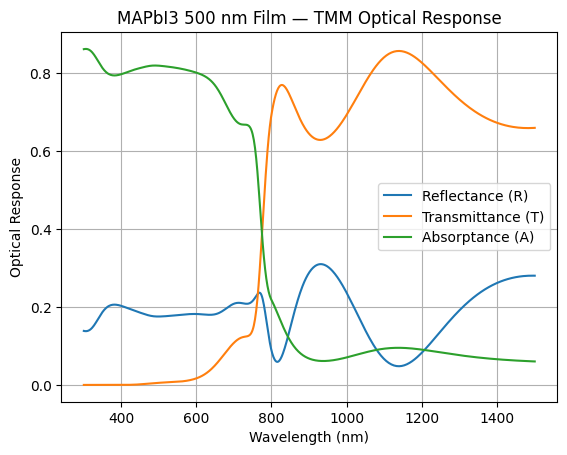

In [17]:
import matplotlib.pyplot as plt

plt.plot(data["Wavelength (nm)"], data["R"], label="Reflectance (R)")
plt.plot(data["Wavelength (nm)"], data["T"], label="Transmittance (T)")
plt.plot(data["Wavelength (nm)"], data["A"], label="Absorptance (A)")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Optical Response")
plt.title("MAPbI3 500 nm Film — TMM Optical Response")
plt.legend()
plt.grid()
plt.show()

#### Interpretation of A, T, and R

At wavelengths shorter than the absorption edge (~780 nm), the MAPbI₃ layer exhibits high absorptance (A ≈ 0.7–0.85), while transmittance remains low. This strong absorption is consistent with the relatively large k values in the absorbing region. Near ~780 nm, absorptance decreases sharply and transmittance increases as k approaches zero, indicating the transition toward weak optical absorption. Reflectance remains comparatively moderate (approximately 0.05–0.3) and shows wavelength-dependent oscillations, which arise from thin-film interference in the 500 nm MAPbI₃ layer.

### Energy Conservation Check

As a validity check on the TMM implementation, R + T + A was verified to 
equal 1 across the wavelength range.

In [18]:
# Check energy conservation

data["R_plus_T_plus_A"] = data["R"] + data["T"] + data["A"]

print("Minimum R + T + A:", data["R_plus_T_plus_A"].min())
print("Maximum R + T + A:", data["R_plus_T_plus_A"].max())

Minimum R + T + A: 0.9999999999999999
Maximum R + T + A: 1.0


### Effect of Film Thickness on R, T, and A 
To investigate the effect of film thickness on the optical response, R, T, and A were calculated for MAPbI₃ film thicknesses ranging from 100 nm to 1000 nm.

In [19]:
def calculate_tmm(thickness):

    R = []
    T = []
    A = []

    for wavelength, n_film_value in zip(
        data["Wavelength (nm)"],
        data["n_complex"]
    ):

        n_list = [
            n_air,
            n_film_value,
            n_glass.iloc[0]
        ]

        d_list = [
            d_air,
            thickness,
            d_glass
        ]

        result_s = coh_tmm("s", n_list, d_list, 0, wavelength)
        result_p = coh_tmm("p", n_list, d_list, 0, wavelength)

        R_avg = (result_s["R"] + result_p["R"]) / 2
        T_avg = (result_s["T"] + result_p["T"]) / 2

        R.append(R_avg)
        T.append(T_avg)
        A.append(1 - R_avg - T_avg)

    return np.array(R), np.array(T), np.array(A)

In [20]:
# Calculate TMM response for different MAPbI3 thicknesses

thicknesses = [100, 300, 500, 700, 1000]

results = {}

for thickness in thicknesses:
    R, T, A = calculate_tmm(thickness)
    
    results[thickness] = {
        "R": R,
        "T": T,
        "A": A
    }

print("Thickness study completed.")

Thickness study completed.


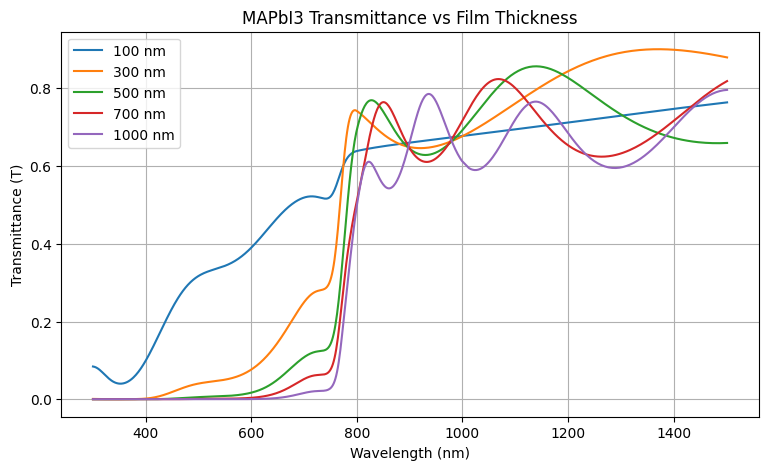

In [21]:
plt.figure(figsize=(9, 5))

for thickness in thicknesses:
    plt.plot(
        data["Wavelength (nm)"],
        results[thickness]["T"],
        label=f"{thickness} nm"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmittance (T)")
plt.title("MAPbI3 Transmittance vs Film Thickness")
plt.legend()
plt.grid()
plt.show()

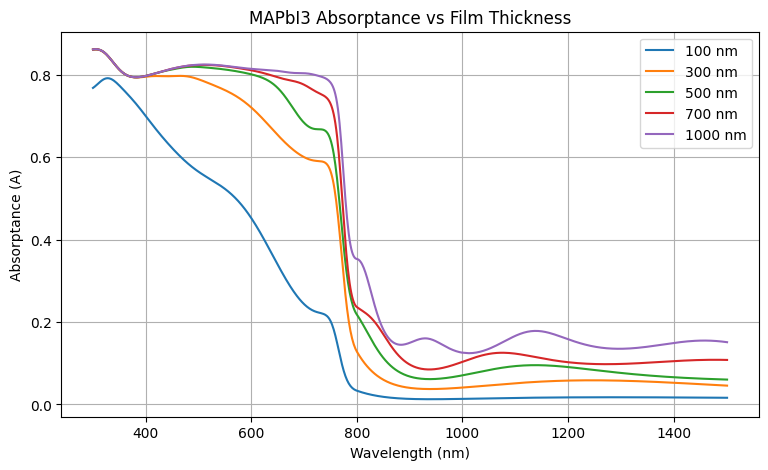

In [22]:
plt.figure(figsize=(9, 5))

for thickness in thicknesses:
    plt.plot(
        data["Wavelength (nm)"],
        results[thickness]["A"],
        label=f"{thickness} nm"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorptance (A)")
plt.title("MAPbI3 Absorptance vs Film Thickness")
plt.legend()
plt.grid()
plt.show()

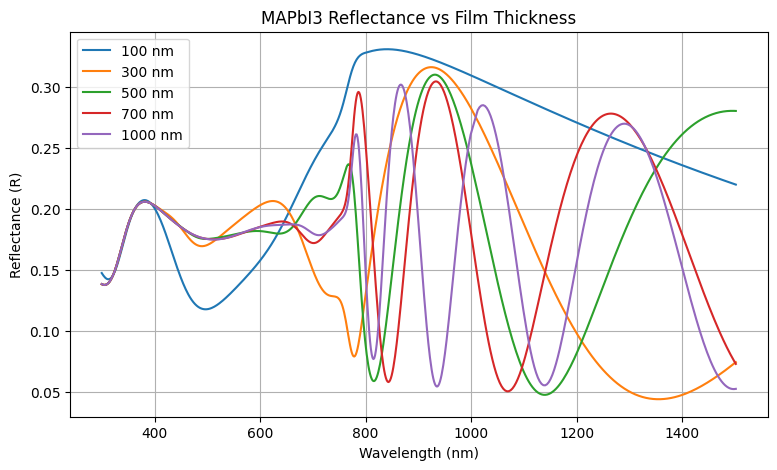

In [23]:
plt.figure(figsize=(9, 5))

for thickness in thicknesses:
    plt.plot(
        data["Wavelength (nm)"],
        results[thickness]["R"],
        label=f"{thickness} nm"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (R)")
plt.title("MAPbI3 Reflectance vs Film Thickness")
plt.legend()
plt.grid()
plt.show()

#### Interpretation of Thickness Dependence

Below the absorption edge (~780 nm), thinner MAPbI₃ films show higher transmittance and lower absorptance because less material is available to absorb the incident light. For example, the 100 nm film shows substantially higher transmission, whereas the thicker 500–1000 nm films exhibit much stronger absorption (A ≈ 0.8). Above ~780 nm, transmittance increases for all thicknesses as the extinction coefficient k becomes very small. The thicker films also show more pronounced interference fringes, particularly in reflectance, due to the increased optical path length and thin-film interference.

### Absorption Coefficient

The absorption coefficient (α) was calculated from the extinction coefficient (k) to examine the wavelength-dependent light absorption of MAPbI₃.

In [24]:
# Calculate absorption coefficient

wavelength_nm = data["Wavelength (nm)"]
k = data["k"]

data["alpha_cm-1"] = (4 * np.pi * k / wavelength_nm) * 1e7

data[["Wavelength (nm)", "k", "alpha_cm-1"]].head()

,Wavelength (nm),k,alpha_cm-1
0,300.009583,0.559247,234249.352860
1,301.600861,0.563854,234932.961162
2,303.192139,0.569127,235885.430019
3,304.783417,0.575073,237105.434392
4,306.374725,0.581694,238589.602590


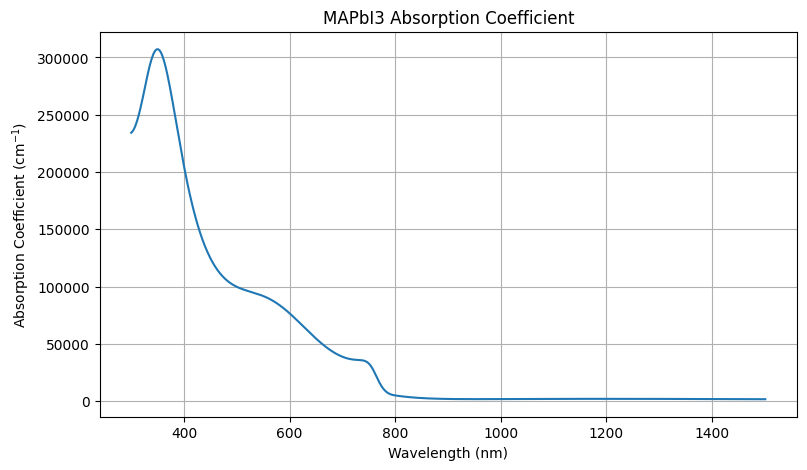

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    data["Wavelength (nm)"],
    data["alpha_cm-1"]
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorption Coefficient (cm$^{-1}$)")
plt.title("MAPbI3 Absorption Coefficient")
plt.grid()
plt.show()

#### Interpretation of Absorption Coefficient (α)

The absorption coefficient (α) reaches ~3 × 10⁵ cm⁻¹ near 350 nm, reflecting the strong UV absorption indicated by the high k values. It then decreases with increasing wavelength and drops sharply near ~780 nm, marking the absorption edge. Beyond the absorption edge, α decreases to approximately 10
3
 cm
−1
 or lower, indicating substantially weaker absorption in the NIR region, consistent with the near-zero k values.

### Angle-Dependent Optical Response

The optical response of the 500 nm MAPbI₃ film was further examined at incidence angles of 0°, 30°, and 60° to assess the angular dependence of R, T, and A.

In [26]:
def calculate_tmm_angle(thickness, angle_deg):

    R = []
    T = []
    A = []

    angle_rad = np.radians(angle_deg)

    for wavelength, n_film_value in zip(
        data["Wavelength (nm)"],
        data["n_complex"]
    ):

        n_list = [
            n_air,
            n_film_value,
            n_glass.iloc[0]
        ]

        d_list = [
            d_air,
            thickness,
            d_glass
        ]

        result_s = coh_tmm("s", n_list, d_list, angle_rad, wavelength)
        result_p = coh_tmm("p", n_list, d_list, angle_rad, wavelength)

        R_avg = (result_s["R"] + result_p["R"]) / 2
        T_avg = (result_s["T"] + result_p["T"]) / 2

        R.append(R_avg)
        T.append(T_avg)
        A.append(1 - R_avg - T_avg)

    return np.array(R), np.array(T), np.array(A)

In [27]:
# Calculate angle-dependent TMM response

angles = [0, 30, 60]

angle_results = {}

for angle in angles:
    R_angle, T_angle, A_angle = calculate_tmm_angle(500, angle)

    angle_results[angle] = {
        "R": R_angle,
        "T": T_angle,
        "A": A_angle
    }

print("Angle-dependent TMM calculation completed.")

Angle-dependent TMM calculation completed.


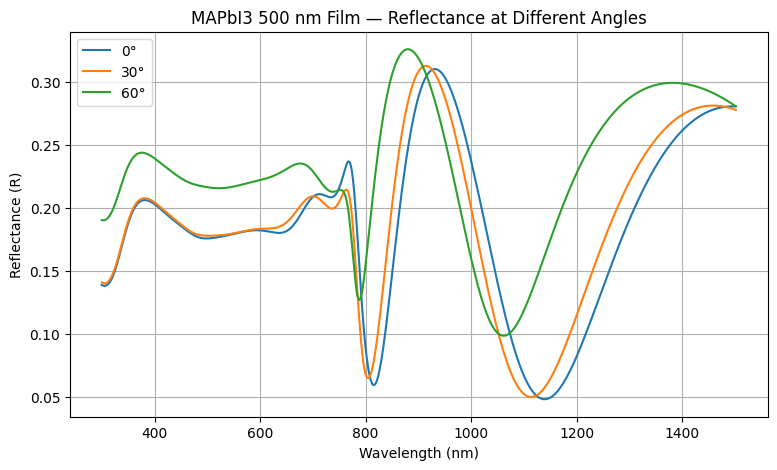

In [28]:
# Reflectance vs incident angle

plt.figure(figsize=(9, 5))

for angle in angles:
    plt.plot(
        data["Wavelength (nm)"],
        angle_results[angle]["R"],
        label=f"{angle}°"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (R)")
plt.title("MAPbI3 500 nm Film — Reflectance at Different Angles")
plt.legend()
plt.grid()
plt.show()

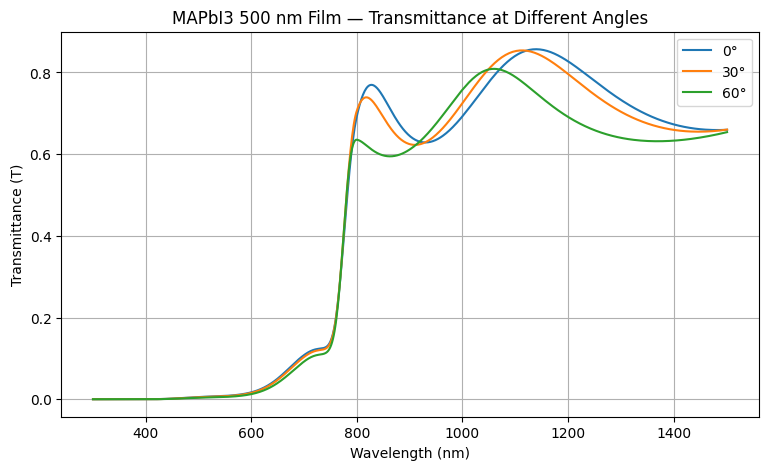

In [29]:
plt.figure(figsize=(9, 5))

for angle in angles:
    plt.plot(
        data["Wavelength (nm)"],
        angle_results[angle]["T"],
        label=f"{angle}°"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmittance (T)")
plt.title("MAPbI3 500 nm Film — Transmittance at Different Angles")
plt.legend()
plt.grid()
plt.show()

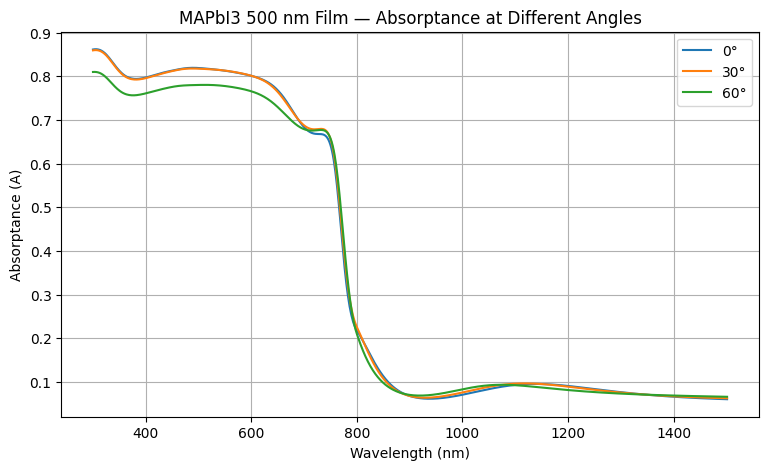

In [30]:
plt.figure(figsize=(9, 5))

for angle in angles:
    plt.plot(
        data["Wavelength (nm)"],
        angle_results[angle]["A"],
        label=f"{angle}°"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorptance (A)")
plt.title("MAPbI3 500 nm Film — Absorptance at Different Angles")
plt.legend()
plt.grid()
plt.show()

#### Interpretation of Angle-Dependent Optical Response

Absorptance remains relatively stable in the strong-absorption region (~300–700 nm), with only a slight decrease at higher incidence angles (~0.86 to ~0.81 at 60°), mainly due to increased reflectance. Reflectance shows the strongest angular dependence, with interference fringes becoming more pronounced and shifting with increasing angle because of changes in the optical path within the thin film. Transmittance is also relatively insensitive to angle in the strongly absorbing region but decreases modestly at higher angles beyond ~800 nm, where reflection becomes more significant.

### Comparison with Experimental EQE

To compare the TMM results with experimental device behavior, the simulated absorptance was compared with an experimentally measured external quantum efficiency (EQE) spectrum digitized from Lin et al. (2015).

In [31]:
df_exp = pd.read_csv("Optical_data/520nm_dataset.csv" , skiprows=1)
df_exp = df_exp.sort_values('X').reset_index(drop=True)

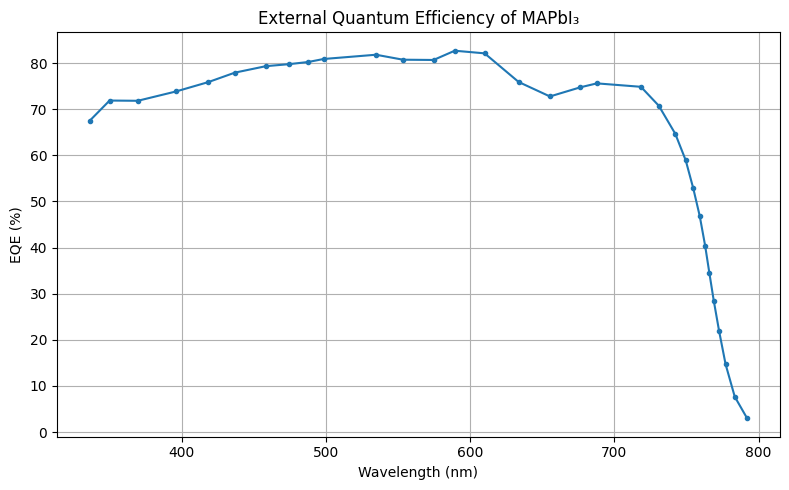

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(df_exp["X"], df_exp["Y"], "o-", markersize=3)

plt.xlabel("Wavelength (nm)")
plt.ylabel("EQE (%)")
plt.title("External Quantum Efficiency of MAPbI₃")

plt.grid(True)
plt.tight_layout()
plt.show()

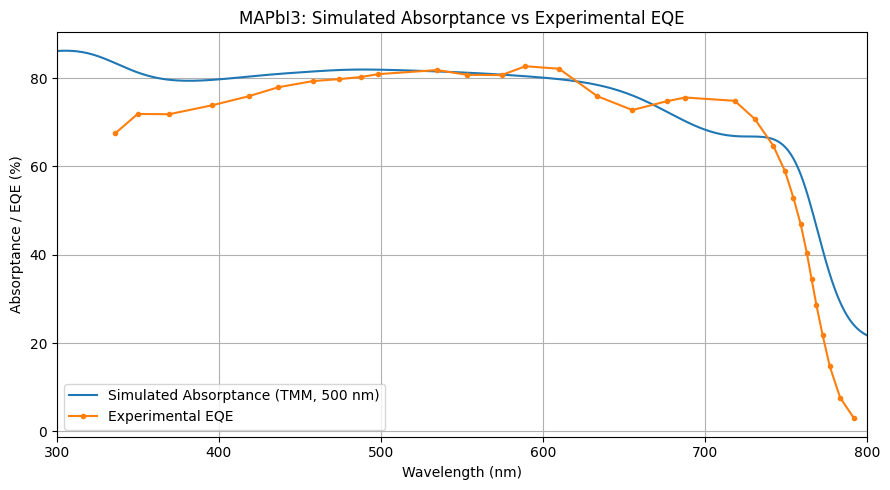

In [33]:
plt.figure(figsize=(9, 5))

plt.plot(data["Wavelength (nm)"], results[500]["A"] * 100, label="Simulated Absorptance (TMM, 500 nm)")
plt.plot(df_exp["X"], df_exp["Y"], "o-", markersize=3, label="Experimental EQE")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorptance / EQE (%)")
plt.title("MAPbI3: Simulated Absorptance vs Experimental EQE")
plt.xlim(300, 800)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation of EQE Comparison

The simulated absorptance of the 500 nm MAPbI₃ film follows a similar wavelength-dependent trend to the experimental EQE spectrum reported by Lin et al. (2015). Both show strong response in the visible region followed by a sharp decrease near the MAPbI₃ absorption edge (~780 nm). The lower experimental EQE compared with the simulated absorptance is expected because EQE also depends on carrier generation, transport, recombination, and device losses that are not included in the optical TMM model.


### Conclusion
This work extended the structural study of MAPbI₃ perovskite thin films to their optical properties using literature-based n and k data and the Transfer Matrix Method (TMM). An Air/MAPbI₃/Glass structure was used to study the reflectance, transmittance, and absorptance of a 500 nm MAPbI₃ film. The calculated values satisfied the energy conservation condition, R + T + A = 1, showing that the TMM calculations were consistent. The results showed strong absorption below the ~780 nm absorption edge, which agrees with the reported bandgap of MAPbI₃ of about 1.6 eV. Increasing the film thickness also increased the absorptance because light travels through a greater thickness of the absorbing material. When the angle of incidence was increased, reflectance showed the strongest change, mainly due to interference effects in the thin film, while absorptance and transmittance changed less in the strongly absorbing region. The simulated absorptance also showed a similar spectral trend and absorption edge to the experimental EQE data from Lin et al. (2015). The difference between absorptance and EQE is expected because EQE is also affected by processes such as carrier recombination and transport, which are not included in the optical model. Overall, this study shows how literature optical data and TMM can be used to understand the optical behavior of MAPbI₃ thin films and provides a useful starting point for more detailed optical modeling of perovskite solar cells.
